In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np
import seaborn as sns

In [73]:
df = pd.read_csv('dataset_riesgo_hipertension.csv')
print(df.head())
print(df.info())
print(df.describe())

   Edad   IMC  PresionArterial  ConsumoSal  ActividadFisica  \
0    56  38.0            155.3           4                1   
1    69  23.5            177.8           4                1   
2    46  27.0            136.5           1                1   
3    32  34.6            119.1           1                4   
4    60  23.0            161.6           2                2   

   RiesgoHipertension  
0                   1  
1                   1  
2                   0  
3                   0  
4                   1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                200 non-null    int64  
 1   IMC                 200 non-null    float64
 2   PresionArterial     200 non-null    float64
 3   ConsumoSal          200 non-null    int64  
 4   ActividadFisica     200 non-null    int64  
 5   RiesgoHipertension  200 n

In [7]:
df.columns

Index(['Edad', 'IMC', 'PresionArterial', 'ConsumoSal', 'ActividadFisica',
       'RiesgoHipertension'],
      dtype='object')

In [10]:
df["Edad"].value_counts()

,count
Edad,
77,9
41,7
61,7
79,7
25,6
32,6
31,6
56,6
52,6


<Axes: xlabel='Edad', ylabel='RiesgoHipertension'>

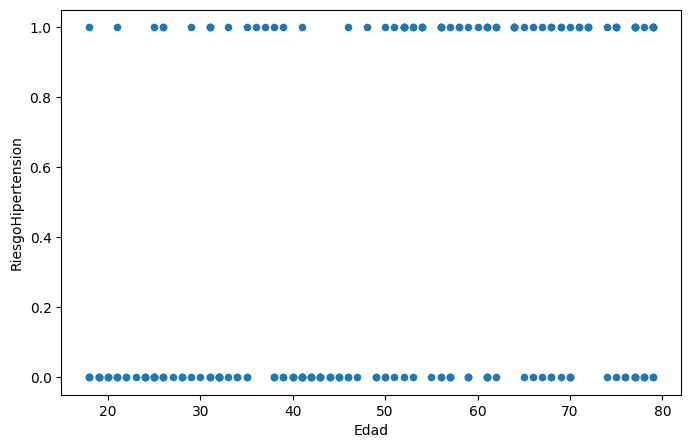

In [11]:
df.plot(kind='scatter', x='Edad', y='RiesgoHipertension', figsize=(8,5))

In [69]:
# Definición de las Variables
# Características (X) y Variable Objetivo (y)
features = ['Edad', 'IMC', 'PresionArterial', 'ConsumoSal', 'ActividadFisica']
target = 'RiesgoHipertension'

In [70]:
X = df[features]
y = df[target]

In [71]:
# --- 3. Dividir los Datos ---
# Dividimos el 80% para entrenamiento y el 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [74]:
X_test.count()

,0
Edad,60
IMC,60
PresionArterial,60
ConsumoSal,60
ActividadFisica,60


In [64]:
# --- 4. Entrenar el Modelo de Regresión Logística ---
laRegresion=LogisticRegression(max_iter=200)

# Entrenamiento
laRegresion.fit(X_train,y_train)

LogisticRegression(max_iter=200)

In [90]:
df.sample()

,Edad,IMC,PresionArterial,ConsumoSal,ActividadFisica,RiesgoHipertension
14,41,37.6,104.1,2,1,0


In [68]:
# Predicciones
valor = laRegresion.predict([[75,29.4,167.0,1,1]])
print(valor)


[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [79]:
y_pred = laRegresion.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 0 1 0 0 0 0 0 0
 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0]


In [76]:
print (laRegresion.coef_)
print (laRegresion.intercept_)


[[ 0.10687173  0.32500203  0.10725232  1.24477295 -1.70351044]]
[-29.27945642]


In [84]:
edad = int(input("Digite Edad:  "))
imc = float(input("Digite IMC: "))
pArterial = float(input("Digite Presion Arterial: "))
cSal = int(input("Digite Consumo Sal - de 1 al 5: "))
aFisica = int(input("Digite Actividad Fisica - de 1 a 5: "))

h = laRegresion.intercept_[0] + (ce[0]*edad) + (ce[1]*imc) + (ce[2]*pArterial) + (ce[3]*cSal) + (ce[4]*aFisica)
salidaFinal =  1 / (1 + np.exp(-h))
#math.e ** (-h)

if salidaFinal >= 0.5:
    print("Tiene riesgo de hipertensión "+str(salidaFinal))
else:
    print("No tiene riesgo de hipertesión "+str(salidaFinal))

Digite Edad:  75
Digite IMC: 29.3
Digite Presion Arterial: 167.2
Digite Consumo Sal - de 1 al 5: 3
Digite Actividad Fisica - de 1 a 5: 2
riesgo hipertensión 0.6501910932837526


In [86]:
y_pred=laRegresion.predict(x_test)
matrixC = metrics.confusion_matrix(y_test,y_pred)
print(matrixC)


[[38  4]
 [ 5 13]]


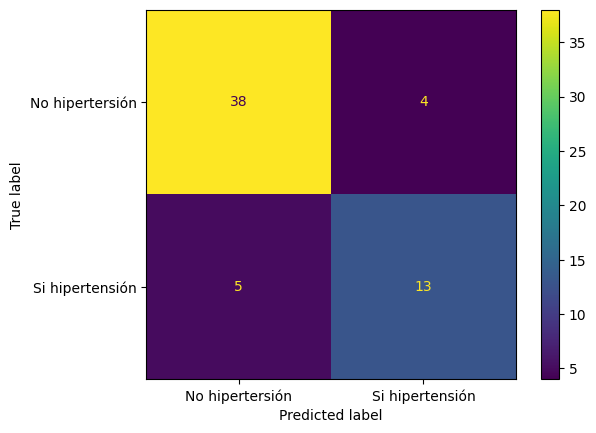

In [87]:
cm_display = metrics.ConfusionMatrixDisplay(matrixC, display_labels = ['No hipertersión', 'Si hipertensión'])
cm_display.plot()
plt.show()

In [96]:
#Accurary (Exactitud)
print (metrics.accuracy_score(y_test,y_pred))

0.85


In [97]:
error = 1 - metrics.accuracy_score(y_test,y_pred)
print(f"Error: {error:.4f}")

Error: 0.1500


In [92]:
#Presicion (Presición)
print (metrics.precision_score(y_test,y_pred))

0.7647058823529411


In [93]:
#Recall (Exhaustividad)
print (metrics.recall_score(y_test,y_pred))

0.7222222222222222


In [94]:
#F1 Score
print (metrics.f1_score(y_test,y_pred))

0.7428571428571429
